Modern deep learning frameworks abstract away the mechanics of training. This notebook removes those abstractions and rebuilds the process from the ground up. Using only NumPy, it implements forward computation, manual backpropagation, and gradient-based optimization, exposing the full training loop that underlies neural network learning.

The notebook begins with linear regression examples, then introduces a ReLU-based network to model a simple nonlinear target. In the next notebook, I will introduce the Softmax activation function and the Cross-Entropy loss.

In [41]:
# importing libraries
import random
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

# set seeds for reproducibility
seed = 42

def set_seeds(seed):
  random.seed(seed)
  np.random.seed(seed)

set_seeds(seed)

# Linear function

A linear function is typically represented as:

$$f(x) = wx + b$$

Here is the NumPy version of the equations.

In [42]:
def linear_fn(x, w, b):
  return w * x + b

def ground_truth(x):
  # example f(x) = wx + b
  return linear_fn(x, 2.0, 1.0)

# we know that w is 2.0 and b is 1.0
X = np.array([1, 3, 5, 7], dtype=float)
y = np.array(list(map(ground_truth, X)), dtype=float)
print(f"X: {X}")
print(f"y: {y}")

X: [1. 3. 5. 7.]
y: [ 3.  7. 11. 15.]


# Mean squared error

But how do we train a model so that the learned value of w becomes 2 and the value of b becomes 1?

1. Make a prediction using random values for w and b.
2. Calculate how wrong the prediction is.
3. Update the values w and b based on how wrong the prediction was.

We can calculate how wrong we are using this formula:
$$
L = \frac{1}{n} \sum (\hat{y} - y)^2
$$

This is actually **mean squared error**.

In [43]:
# start with random values for w and b, close to 0
w = random.uniform(-1.0, 1.0)
b = random.uniform(-1.0, 1.0)

# make a single prediction
y = ground_truth(1)
yHat = linear_fn(1, w, b)

# calculate the error using the formula
error = np.mean((yHat - y) ** 2)
print(f"Predicted {yHat:.2f}, with error {error:.2f}")

Predicted -0.67, with error 13.48


Running the previous cell a couple of times produces different predictions with different errors. This happens because the parameters are initialized randomly.

The next step is to update \( w \) and \( b \) so that they move closer to the ground-truth values.

**Basic rule: The derivative of a squared number is two times the number**

$$
\frac{d}{dx}(x^2) = 2x
$$

For a single squared error term,

$$
\frac{\partial}{\partial \hat{y}_i} (\hat{y}_i - y_i)^2 = 2(\hat{y}_i - y_i)
$$

For the full mean squared error, since we average over all elements, the derivative with respect to the predictions is

$$
\frac{\partial L}{\partial \hat{y}} = \frac{2}{N}(\hat{y} - y)
$$

where $(N)$ is the total number of elements in $(y)$.

In [44]:
error = np.mean((yHat - y) ** 2)
print(f"Predicted {yHat:.2f}, with error {error:.2f}")

loss_dy = 2 * (yHat - y) / np.size(y)
print(f"Derivative {loss_dy}")

Predicted -0.67, with error 13.48
Derivative -7.342249785277797


# Gradient descent
Since MSE averages the squared error over all elements in the output, its gradient is scaled by the same averaging factor.

$$
\frac{\partial L}{\partial \hat{y}} = \frac{2}{n}(\hat{y} - y)
$$

Since $\hat{y} = wx + b$,

$$
\frac{\partial \hat{y}}{\partial w} = x
\qquad \text{and} \qquad
\frac{\partial \hat{y}}{\partial b} = 1
$$

Therefore we can calculate (dW) and (db) based on the chain rule,

$$
dW = \frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot x
$$

$$
db = \frac{\partial L}{\partial b} = \frac{\partial L}{\partial \hat{y}}
$$

We then update the parameters using this formula:

$$
W = W - \eta \cdot dW
$$

$$
b = b - \eta \cdot db
$$

where \( $\eta$ \) is a small floating-point value called the learning rate.

We repeat this process multiple times so that \( w \) and \( b \) gradually get closer to the ground-truth values.

This is **gradient descent**.

In this notebook, I use **batch gradient descent**, because the gradients are computed using all training samples at each step.

In [45]:
# reinit X and y
X = np.array([1, 3, 5, 7], dtype=float)
y = np.array(list(map(ground_truth, X)), dtype=float)

# reinit with random values for w and b, close to 0
w = random.uniform(-1.0, 1.0)
b = random.uniform(-1.0, 1.0)

eta = 0.01
n = len(X)

for epoch in range(1000):

    # make a prediction
    yHat = w * X + b

    # calculate the loss
    mse = np.mean((y - yHat) ** 2)

    # calculate gradients
    dw = (2/n) * np.sum(X * (yHat - y))
    db = (2/n) * np.sum(yHat - y)

    # update the initial values(weight and bias)
    w = w - eta * dw
    b = b - eta * db


print("After Train Results")
# Expecting w to be close to 2, and b to 1
print(f"w: {w} b: {b}")

After Train Results
w: 2.0020111558064233 b: 0.9895569077487354


This is great for scalars. What if we have multiple features?

We modify the formula to
$$f(x) = Wx + b$$

which translates to

$$
f(x) = w_1 x_1 + w_2 x_2 + b
$$


For this to work, we need to match the number of features and the weights and we only need one bias per output.

In [46]:
# two features per sample and a single target
X = np.array([[1, 2], [2, 1], [3, 4], [4, 3]], dtype=float)
y = (2 * X[:, [0]] + 1 * X[:, [1]] + 1).astype(float)

n_features = X.shape[1]
n_output_features = y.shape[1]

w = np.random.uniform(-1.0, 1.0, size=(n_features, n_output_features))
b = np.random.uniform(-1.0, 1.0, size=(1, n_output_features))

lr = 0.01 # eta
n_samples = len(X) # Number of samples

for epoch in range(2000): # Increased epochs for better convergence

    # make a prediction
    yHat = X @ w + b # (n_samples, n_output_features)

    # calculate the loss
    mse = np.mean((y - yHat) ** 2)

    # calculate the derivative of the loss function
    dloss_dy = 2 * (yHat - y) / y.size

    # calculate gradients
    dw = X.T @ dloss_dy
    db = np.sum(dloss_dy, axis=0, keepdims=True)

    # update the weights and biases
    w = w - lr * dw
    b = b - lr * db

print("After Train Results")
print(f"w: {w} b: {b}")

After Train Results
w: [[2.00011382]
 [1.00011382]] b: [[0.99934578]]


## Problems with gradient descent

**Exploding and vanishing gradients** happen when gradients are repeatedly multiplied during backpropagation through many layers. Depending on the weight matrices and activation derivatives, these products can either grow very large or shrink toward zero.


# Weight initializations

In modern deep learning, there are many techniques to mitigate these issues, such as learning rate schedulers, gradient clipping, and advanced optimizers.

A practical way to reduce these problems at initialization time is to choose weight scales that match the activation function, such as He initialization for ReLU networks or Xavier initialization when using Sigmoid.

> A full discussion of initialization strategies deserves its own notebook, but for now I will include He, Xavier, and standard initialization in the LinearLayer implementation.

# Creating a Linear Layer Class

Let's wrap this into a LinearLayer class and test it using generated data. I have also defined a BaseLayer that sets the frame for layers implemented in the future.

In [47]:
class BaseLayer(ABC):

  # unused in this notebook, but useful for future implementation
  is_training: bool

  def train(self):
    self.is_training = True

  def eval(self):
    self.is_training = False

  @abstractmethod
  def forward(self, x):
    pass

  @abstractmethod
  def backward(self, dout):
    pass

  def step(self, lr):
    pass

In [48]:
class LinearLayer(BaseLayer):
  def __init__(self, in_features:int, out_features:int, initialization: str = "he"):

    if initialization == "he":
        scale = np.sqrt(2.0 / in_features)
    elif initialization == "xavier":
        scale = np.sqrt(1.0 / in_features)
    elif initialization == "standard":
        scale = 0.01
    else:
        raise ValueError(f"Unknown init: {initialization}")

    self.w = np.random.randn(in_features, out_features) * scale

    self.b = np.zeros((1, out_features)) # we need one bias per output feature

  def forward(self, x):
    self.x = x
    return x @ self.w + self.b

  def backward(self, dout):
    self.dw = self.x.T @ dout
    self.db = np.sum(dout, axis=0, keepdims=True)
    dx = dout @ self.w.T
    return dx

  def step(self, lr):
    self.w = self.w - (self.dw * lr)
    self.b = self.b - (self.db * lr)

In [49]:
# two features per sample and the target is (feature1 * 2 + feature2 * 1 + 1)
X = np.array([[1, 2], [2, 1], [3, 4], [4, 3]], dtype=float)
y = (2 * X[:, [0]] + 1 * X[:, [1]] + 1).astype(float)

ll = LinearLayer(in_features=2, out_features=1)

lr = 0.01 # eta
n_samples = len(X)

for epoch in range(2000):

    # make a prediction
    yHat = ll.forward(X)

    # calculate the loss
    mse = np.mean((y - yHat) ** 2)

    # calculate the derivative of the loss function
    dloss_dy = 2 * (yHat - y) / y.size

    # update gradients
    ll.backward(dloss_dy)

    ll.step(lr)

print("After Train Results")
print(f" After train results: w0: {ll.w[0]} w1: {ll.w[1]} b: {ll.b[0]}")
print(f"    Expected results: w0: {2.0} w1: {1.0} b: {1}")

After Train Results
 After train results: w0: [2.00030419] w1: [1.00030419] b: [0.99825153]
    Expected results: w0: 2.0 w1: 1.0 b: 1


# ReLU activation function

Many real-world relationships are nonlinear, so we need activation functions such as ReLU(Rectified Linear Unit) to model them.

$$
A = \max(0, Z)
$$

and **ReLU** derivative

$$
\text{ReLU}'(x) =
\begin{cases}
1, & x > 0 \\
0, & x \le 0
\end{cases}
$$


In [50]:
class ReLU(BaseLayer):

  def forward(self, x):
      self.x = x
      return np.maximum(0, x)

  def backward(self, dout):
      dx = dout * (self.x > 0.0)
      return dx

In [51]:
set_seeds(seed)
ll1 = LinearLayer(in_features=2, out_features=3)
relu = ReLU()
ll2 = LinearLayer(in_features=3, out_features=1)

X = np.array([[1, 2], [2, 1], [3, 1], [1, 3], [4, 2], [2, 4]], dtype=float)
# define a nonlinear target
y = np.maximum(0, X[:, [0]] - X[:, [1]]) + 1

lr = 0.05
n = len(X)

losses = []

for epoch in range(500):

  # forward pass
  x = ll1.forward(X)
  x = relu.forward(x)

  yHat = ll2.forward(x)

  # calculate the loss
  mse = np.mean((y - yHat) ** 2)
  losses.append(mse)

  # derivative of loss function
  dloss_dy = 2 * (yHat - y) / y.size

  # gradient descent
  grad = ll2.backward(dloss_dy)
  grad = relu.backward(grad)
  grad = ll1.backward(grad)

  ll1.step(lr)
  ll2.step(lr)


x_test = np.array([[1, 2]])
y_test = np.maximum(0, x_test[:, [0]] - x_test[:, [1]]) + 1
yHatTest = ll2.forward(relu.forward(ll1.forward(x_test)))
print(f"Test outcome: {yHatTest[0][0]:.2f}, expected {y_test[0][0]}")

Test outcome: 0.99, expected 1


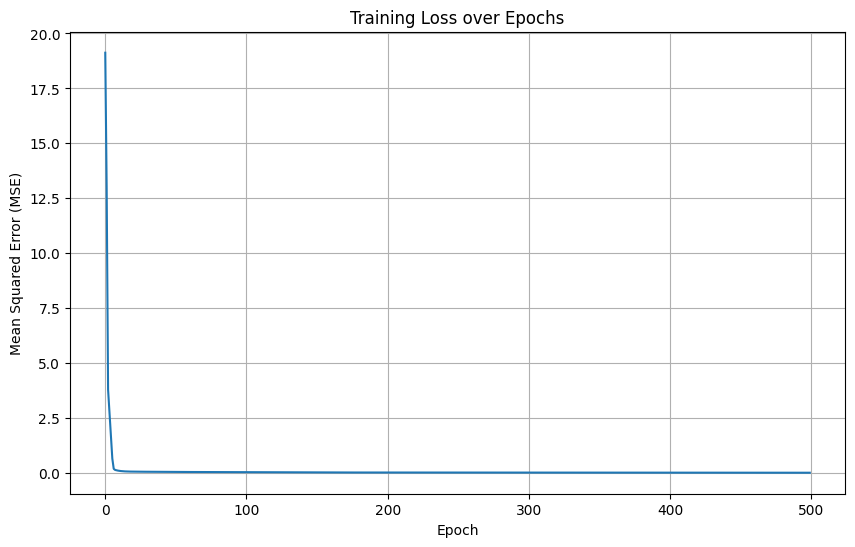

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

# Experiments with learning rate

I will run an experiment with different learning rates and show the effect it has on learning.


Starting training with learning rate: 0.1
Finished training with learning rate: 0.1, Final MSE: 0.8056

Starting training with learning rate: 0.05
Finished training with learning rate: 0.05, Final MSE: 0.0071

Starting training with learning rate: 0.01
Finished training with learning rate: 0.01, Final MSE: 0.0635

Starting training with learning rate: 0.001
Finished training with learning rate: 0.001, Final MSE: 1.0177


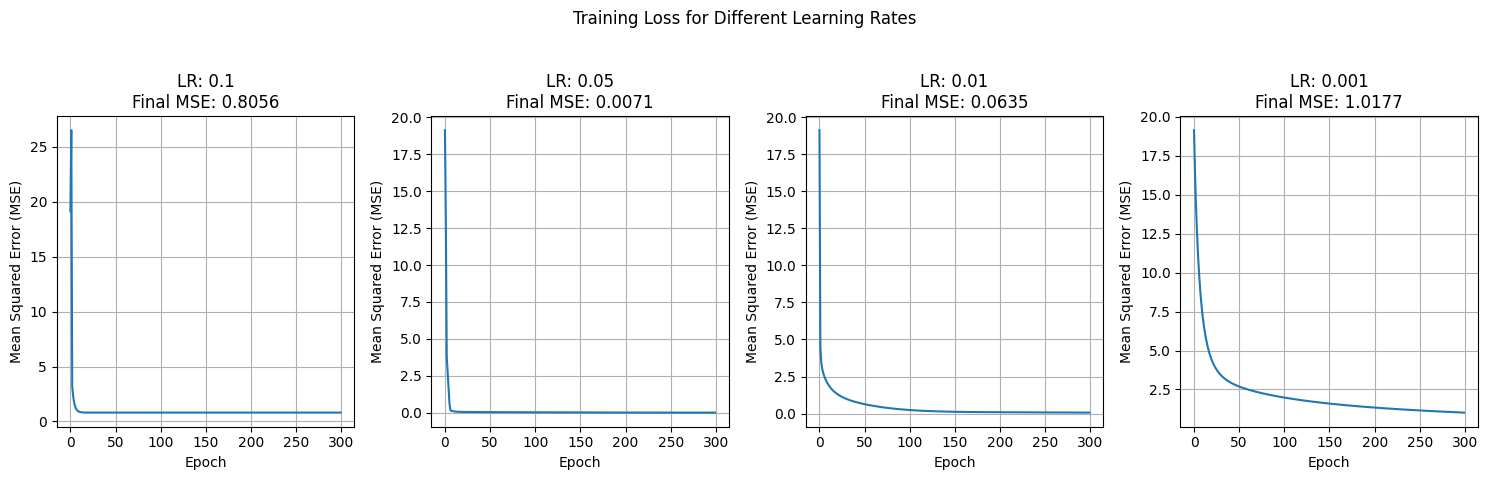

In [53]:
learning_rates = [0.1, 0.05, 0.01, 0.001]
all_losses = {}

X = np.array([[1, 2], [2, 1], [3, 1], [1, 3], [4, 2], [2, 4]], dtype=float)
y = np.maximum(0, X[:, [0]] - X[:, [1]]) + 1
n = len(X)

num_epochs = 300

for lr in learning_rates:
  print(f"\nStarting training with learning rate: {lr}")

  # set the seeds
  set_seeds(seed)

  # re-initialize layers for each learning rate experiment to ensure fair comparison
  ll1 = LinearLayer(in_features=2, out_features=3)
  relu = ReLU()
  ll2 = LinearLayer(in_features=3, out_features=1)

  current_losses = []

  for epoch in range(num_epochs):
    # forward pass
    x_out = ll1.forward(X)
    x_out = relu.forward(x_out)
    yHat = ll2.forward(x_out)

    # calculate the loss
    mse = np.mean((y - yHat) ** 2)
    current_losses.append(mse)

    # backward pass
    dloss_dy = 2 * (yHat - y) / y.size
    grad = ll2.backward(dloss_dy)
    grad = relu.backward(grad)
    ll1.backward(grad)

    # update weights
    ll1.step(lr)
    ll2.step(lr)

  all_losses[str(lr)] = current_losses
  print(f"Finished training with learning rate: {lr}, Final MSE: {current_losses[-1]:.4f}")

# plot the loss functions in a grid plot
fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 5))
fig.suptitle('Training Loss for Different Learning Rates')

for i, lr_str in enumerate(learning_rates):
  ax = axes[i]
  losses_for_lr = all_losses[str(lr_str)]
  ax.plot(losses_for_lr)
  ax.set_title(f'LR: {lr_str}\nFinal MSE: {losses_for_lr[-1]:.4f}')
  ax.set_xlabel('Epoch')
  ax.set_ylabel('Mean Squared Error (MSE)')
  ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In this experiment, 0.05 gave the lowest final MSE among the tested learning rates.

# Future notebooks

I will continue my exploration with a classification problem. Using the LinearLayer and ReLU, I will classify the different types of IRIS flowers in the commonly used IRIS dataset. I will introduce concepts like one-hot encoding, softmax, and cross-entropy.